# sub-graphs

## dependencies

In [8]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, END, START
from langchain_community.tools import TavilySearchResults
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage

from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

from dotenv import load_dotenv
load_dotenv()  

True

## state

In [9]:
class ChildState(TypedDict):
    messages: Annotated[list, add_messages]

## variables

In [10]:
search_tool = TavilySearchResults(max_results=2, search_depth='basic')
tools = [search_tool]

llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.1)
llm = llm.bind_tools(tools)

## functions

In [11]:
def agent(state: ChildState):
    return {
        'messages': [llm.invoke(state['messages'])]
    }

def tools_router(state: ChildState):
    last_msg = state['messages'][-1]
    if(hasattr(last_msg, "tool_calls") and len(last_msg.tool_calls) > 0):
        return 'tool_node'
    return END

## graph

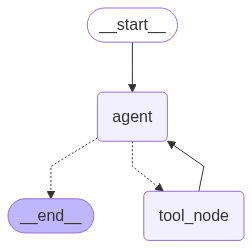

In [23]:
tool_node = ToolNode(tools=tools)

subgraph = StateGraph(ChildState)

subgraph.add_node('agent', agent)
subgraph.add_node('tool_node', tool_node)

subgraph.set_entry_point('agent')

subgraph.add_conditional_edges(
    'agent', 
    tools_router,
    {
        'tool_node': 'tool_node',
        END: END
    }
)
subgraph.add_edge('tool_node', 'agent')

search_app = subgraph.compile()

display(
    Image(
        search_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [ ]:
search_app.invoke({"messages": [HumanMessage(content="How is the weather in Mumbai?")]})

{'messages': [HumanMessage(content='How is the weather in Mumbai?', additional_kwargs={}, response_metadata={}, id='e30330c7-a170-48c1-96aa-aff3dbb61e91'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in Mumbai"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--14995e87-f0d3-4be2-acdc-76ac69ec244a-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in Mumbai'}, 'id': 'c81ca8ee-34a6-4d55-a68d-c0a587dfef96', 'type': 'tool_call'}], usage_metadata={'input_tokens': 81, 'output_tokens': 75, 'total_tokens': 156, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 52}}),
  ToolMessage(content='[{"title": "Weather in Mumbai", "url": "https://www.weatherapi.com/", "content": "{\'location\': {\'name\': \'Mumbai\', \'region\': \'M

# approaches

## Case 1: Shared Schema (Direct Embedding)

In [ ]:
# define parent graph with same schema
class ParentState(TypedDict):
    messages: Annotated[list, add_messages]

# create parent graph
parent_graph1 = StateGraph(ParentState)

# add subgraph as a node in parent graph
parent_graph1.add_node('subagent', search_app)

# connect the flow
parent_graph1.add_edge(START, 'subagent')
parent_graph1.add_edge('subagent', END)

parent_app1 = parent_graph1.compile()

# display(
#     Image(
#         parent_app.get_graph().draw_mermaid_png(
#             draw_method=MermaidDrawMethod.API,
#             max_retries=3,
#             retry_delay=2.0
#         )
#     )
# )

print(parent_app1.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+----------+   
| subagent |   
+----------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [ ]:
parent_app1.invoke({"messages": [HumanMessage(content="How is the weather in Mumbai?")]})

{'messages': [HumanMessage(content='How is the weather in Mumbai?', additional_kwargs={}, response_metadata={}, id='9e3fc37c-9210-4d62-b75a-aa0a92d24a1e'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in Mumbai"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--dbcc18d0-6e10-42dd-a5bd-53f7822c7b4e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in Mumbai'}, 'id': 'd4db7c82-505f-4329-aab7-bb1e5983f3b2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 81, 'output_tokens': 75, 'total_tokens': 156, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 52}}),
  ToolMessage(content='[{"title": "Weather in Mumbai", "url": "https://www.weatherapi.com/", "content": "{\'location\': {\'name\': \'Mumbai\', \'region\': \'M

## Case 2: Different Schema (Invoke with Transformation)

In [37]:
# define parent graph with different schema
class DifferentParentState(TypedDict):
    query: str
    response: str

def search_agent(state: DifferentParentState):
    subgraph_input = {
        "messages": [HumanMessage(content=state['query'])]
    }

    # invoke subgraph
    result = search_app.invoke(subgraph_input)

    # transform output to match parent schema
    assistant_msg = result['messages'][-1]
    return {
        'response': assistant_msg.content
    }

parent_graph2 = StateGraph(DifferentParentState)

parent_graph2.add_node('subagent', search_agent)

parent_graph2.add_edge(START, 'subagent')
parent_graph2.add_edge('subagent', END)

parent_app2 = parent_graph2.compile()

print(parent_app2.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+----------+   
| subagent |   
+----------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [38]:
parent_app2.invoke({"query": "How is the weather in Mumbai?", "response": ""})

{'query': 'How is the weather in Mumbai?',
 'response': 'The current weather in Mumbai is Mist with a temperature of 26.2°C, but it feels like 28.8°C. The humidity is 89% and the wind is blowing from the Northwest at 12.2 kph.'}